# Results — Per-Class Classification Report

Runs inference on saved checkpoints and renders a styled table for each random seed.

- **CCSA rs=123** and **CCSA rs=42** each get their own figure
- Metrics: Precision / Recall / F1 / Support per family

In [21]:
import sys
sys.path.append("/home/tommy/Project/PCBSDA/ours")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch_geometric.loader import DataLoader

from configs.gnn.baseline import get_gnn_config
from configs.ccsa.baseline import get_ccsa_config
from src.gnn.models import GCN
from src.transfer_learning.ccsa.models import GCN_CCSA
from src.transfer_learning.ccsa.utils import prepare_ccsa_data, test_model as ccsa_test
from src.gnn.utils import test_model as gnn_test

BASE_PATH = "/home/tommy/Project/PCBSDA"
EMBEDDING = "cbow"

GNN_CACHE_PATH      = f"{BASE_PATH}/ours/outputs/cache/gnn/{EMBEDDING}/gnn.pkl"
GNN_TEST_CACHE_PATH = f"{BASE_PATH}/ours/outputs/cache/gnn/{EMBEDDING}/gnn_test.pkl"
GNN_MODEL_PATH      = f"{BASE_PATH}/ours/outputs/models/gnn/{EMBEDDING}/gnn_model_classification_x86_64_seed_42.pt"
CCSA_MODEL_RS123    = f"{BASE_PATH}/ours/outputs/models/ccsa/{EMBEDDING}/ccsa_best_rs123.pt"
CCSA_MODEL_RS42     = f"{BASE_PATH}/ours/outputs/models/ccsa/{EMBEDDING}/ccsa_best_rs42.pt"

SAVE_DIR = Path(f"{BASE_PATH}/ours/outputs/plots/results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## Run Inference

In [22]:
# --- GNN ---
with open(GNN_CACHE_PATH, 'rb') as f:
    gnn_cache = pickle.load(f)
with open(GNN_TEST_CACHE_PATH, 'rb') as f:
    gnn_test_cache = pickle.load(f)

gnn_label_encoder = gnn_cache['label_encoder']
gnn_target = gnn_test_cache['ARM-32']

ckpt = torch.load(GNN_MODEL_PATH, map_location=DEVICE, weights_only=False)
cfg  = ckpt['config']
gnn_model = GCN(
    num_node_features=cfg['num_node_features'],
    hidden_channels=cfg['hidden_channels'],
    output_channels=cfg['output_channels'],
    num_classes=ckpt['num_classes'],
    num_layers=cfg['num_layers'],
    dropout=cfg['dropout'],
    pooling=cfg['pooling'],
).to(DEVICE)
gnn_model.load_state_dict(ckpt['model_state_dict'])

gnn_loader = DataLoader(gnn_target, batch_size=256, shuffle=False)
print("=== GNN (seed=42, no DA) ===")
result_gnn = gnn_test(gnn_model, gnn_loader, DEVICE, gnn_label_encoder)

=== GNN (seed=42, no DA) ===
Report:
               precision    recall  f1-score   support

      dnsamp       0.82      0.96      0.88        95
      dofloo       0.46      0.24      0.31       300
      gafgyt       0.75      0.77      0.76       300
       kaiji       1.00      1.00      1.00       134
 meterpreter       0.11      0.01      0.03       137
       mirai       0.90      0.85      0.88       300
    mobidash       0.98      0.72      0.83       300
     tsunami       0.35      0.74      0.47       300

    accuracy                           0.65      1866
   macro avg       0.67      0.66      0.65      1866
weighted avg       0.67      0.65      0.64      1866



In [23]:
# --- CCSA rs=123 ---
ccsa_config = get_ccsa_config()
_, _, tgt_train_123, tgt_test_123, label_encoder, num_classes = prepare_ccsa_data(ccsa_config, random_state=123)

def load_ccsa_model(ckpt_path):
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = GCN_CCSA(
        num_node_features=ccsa_config['num_node_features'],
        hidden_channels=ccsa_config['hidden_channels'],
        output_channels=ccsa_config['output_channels'],
        num_classes=num_classes,
        num_layers=ccsa_config['num_layers'],
        dropout=ccsa_config['dropout'],
        pooling=ccsa_config['pooling'],
    ).to(DEVICE)
    model.load_state_dict(state)
    return model

ccsa_model_123 = load_ccsa_model(CCSA_MODEL_RS123)
ccsa_loader_123 = DataLoader(tgt_test_123, batch_size=256, shuffle=False)
print("=== CCSA rs=123 ===")
result_ccsa_123 = ccsa_test(ccsa_model_123, ccsa_loader_123, DEVICE, label_encoder)

載入快取: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_source.pkl
載入快取: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_target.pkl

CCSA Data Summary:
  Source train: 1664, Source val: 417
  Target train (few-shot): 40, Target test: 1826
  Num classes: 8
  Source train distribution: {4: 240, 3: 195, 5: 240, 7: 240, 0: 166, 2: 240, 6: 240, 1: 103}
  Target train distribution: {0: 5, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5}
  Target test distribution: {0: 90, 1: 295, 2: 295, 3: 129, 4: 132, 5: 295, 6: 295, 7: 295}
=== CCSA rs=123 ===
Report:
               precision    recall  f1-score   support

      dnsamp       0.92      1.00      0.96        90
      dofloo       1.00      1.00      1.00       295
      gafgyt       0.86      0.84      0.85       295
       kaiji       1.00      1.00      1.00       129
 meterpreter       0.96      1.00      0.98       132
       mirai       0.87      0.89      0.88       295
    mobidash       1.00      0.97      0.99     

In [24]:
# --- CCSA rs=42 ---
_, _, tgt_train_42, tgt_test_42, _, _ = prepare_ccsa_data(ccsa_config, random_state=42)

ccsa_model_42 = load_ccsa_model(CCSA_MODEL_RS42)
ccsa_loader_42 = DataLoader(tgt_test_42, batch_size=256, shuffle=False)
print("=== CCSA rs=42 ===")
result_ccsa_42 = ccsa_test(ccsa_model_42, ccsa_loader_42, DEVICE, label_encoder)

載入快取: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_source.pkl
載入快取: /home/tommy/Project/PCBSDA/ours/outputs/cache/ccsa/cbow/ccsa_target.pkl

CCSA Data Summary:
  Source train: 1664, Source val: 417
  Target train (few-shot): 40, Target test: 1826
  Num classes: 8
  Source train distribution: {4: 240, 5: 240, 2: 240, 0: 166, 7: 240, 1: 103, 6: 240, 3: 195}
  Target train distribution: {0: 5, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5}
  Target test distribution: {0: 90, 1: 295, 2: 295, 3: 129, 4: 132, 5: 295, 6: 295, 7: 295}
=== CCSA rs=42 ===
Report:
               precision    recall  f1-score   support

      dnsamp       0.97      0.93      0.95        90
      dofloo       1.00      1.00      1.00       295
      gafgyt       0.83      0.67      0.74       295
       kaiji       1.00      1.00      1.00       129
 meterpreter       0.98      1.00      0.99       132
       mirai       0.62      0.94      0.75       295
    mobidash       1.00      0.72      0.84      

## Per-Class Table

In [25]:
from sklearn.metrics import precision_recall_fscore_support

HEADER_BG  = '#2c3e50'
ROW_COLORS = ['#f4f6f8', '#ffffff']
COL_LABELS = ['Family', 'Precision', 'Recall', 'F1', 'Support']

def render_report_table(result, label_encoder, title, save_path):
    classes = list(label_encoder.classes_)
    p, r, f, s = precision_recall_fscore_support(
        result['y_true'], result['y_pred'],
        labels=list(range(len(classes))),
        zero_division=0
    )

    # rows: per class + macro avg + accuracy
    rows = [[cls, f'{pi:.4f}', f'{ri:.4f}', f'{fi:.4f}', str(si)]
            for cls, pi, ri, fi, si in zip(classes, p, r, f, s)]
    rows.append(['macro avg',
                 f"{np.mean(p):.4f}", f"{np.mean(r):.4f}", f"{np.mean(f):.4f}",
                 str(sum(s))])
    rows.append(['accuracy', '—', '—',
                 f"{result['accuracy']:.4f}", str(sum(s))])

    n_rows = len(rows)
    fig_w  = 7.0
    fig_h  = 0.5 * (n_rows + 1) + 0.6
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    table = ax.table(
        cellText=rows,
        colLabels=COL_LABELS,
        loc='center',
        cellLoc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.5)

    # header
    for ci in range(len(COL_LABELS)):
        cell = table[0, ci]
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color='white', fontweight='bold')

    # per-class rows: alternating
    for ri in range(1, len(classes) + 1):
        bg = ROW_COLORS[(ri - 1) % 2]
        for ci in range(len(COL_LABELS)):
            table[ri, ci].set_facecolor(bg)

    # macro avg row
    for ci in range(len(COL_LABELS)):
        table[len(classes) + 1, ci].set_facecolor('#dce8f5')
        table[len(classes) + 1, ci].set_text_props(fontweight='bold')

    # accuracy row
    for ci in range(len(COL_LABELS)):
        table[len(classes) + 2, ci].set_facecolor('#dce8f5')
        table[len(classes) + 2, ci].set_text_props(fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    plt.tight_layout(pad=0.4)
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_path}")

## Render Tables

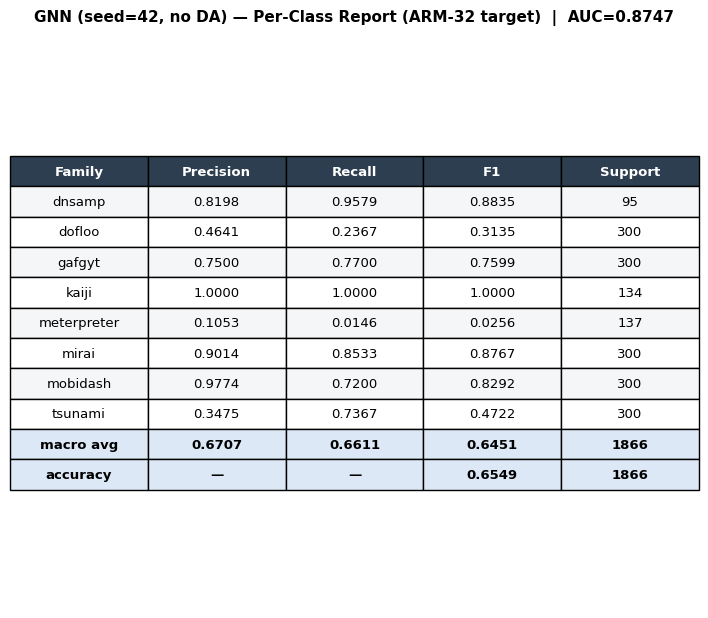

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/results/report_gnn.png


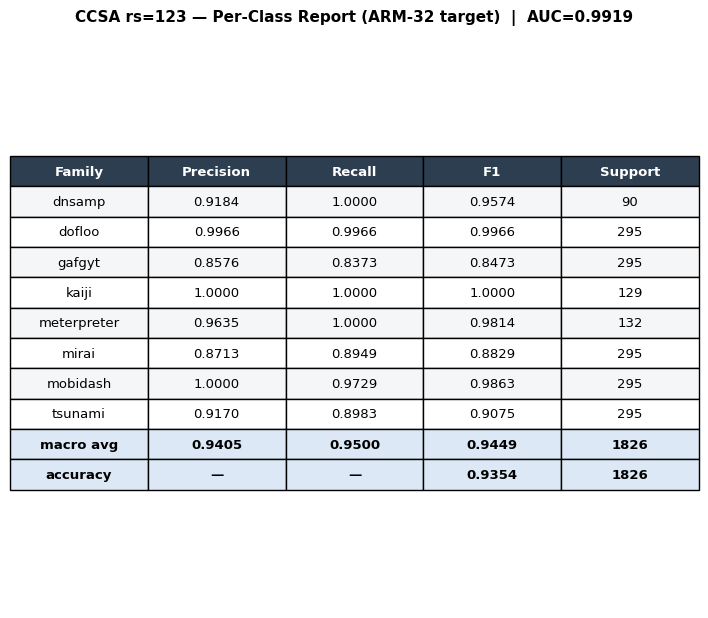

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/results/report_ccsa_rs123.png


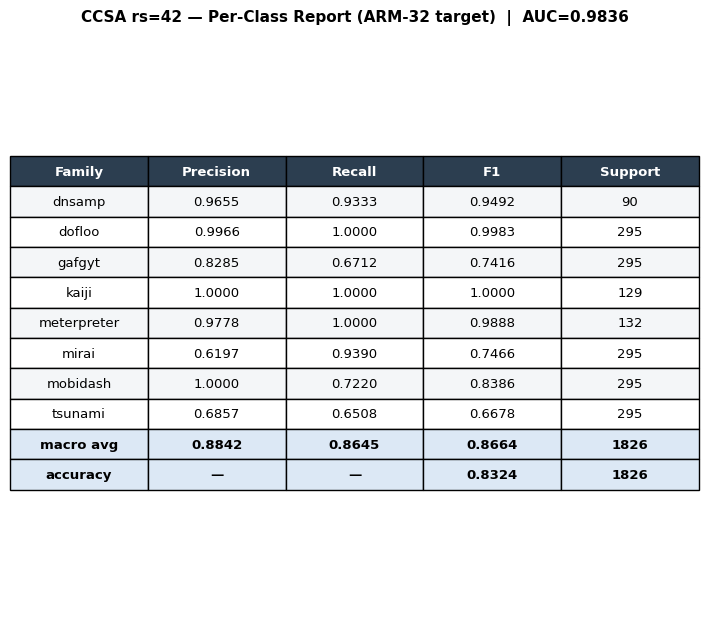

Saved: /home/tommy/Project/PCBSDA/ours/outputs/plots/results/report_ccsa_rs42.png


In [26]:
render_report_table(
    result_gnn, gnn_label_encoder,
    title=f"GNN (seed=42, no DA) — Per-Class Report (ARM-32 target)  |  AUC={result_gnn['auc']:.4f}",
    save_path=SAVE_DIR / "report_gnn.png",
)

render_report_table(
    result_ccsa_123, label_encoder,
    title=f"CCSA rs=123 — Per-Class Report (ARM-32 target)  |  AUC={result_ccsa_123['auc']:.4f}",
    save_path=SAVE_DIR / "report_ccsa_rs123.png",
)

render_report_table(
    result_ccsa_42, label_encoder,
    title=f"CCSA rs=42 — Per-Class Report (ARM-32 target)  |  AUC={result_ccsa_42['auc']:.4f}",
    save_path=SAVE_DIR / "report_ccsa_rs42.png",
)